### This dataset contains house sale prices for King County, which includes Seattle. It includes homes sold between May 2014 and May 2015.19 house features plus the price and the id columns, along with 21613 observations.

## Import libraries and read the dataset

In [322]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from sklearn.model_selection  import train_test_split
from sklearn.cluster import KMeans
from scipy.stats import zscore
from sklearn.preprocessing import Imputer
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve
import sklearn.metrics
from sklearn.linear_model import LinearRegression

In [323]:
housing_df = pd.read_csv("kc_house_data.csv", parse_dates = ['date'])
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
id               21613 non-null int64
date             21613 non-null datetime64[ns]
price            21613 non-null float64
bedrooms         21613 non-null int64
bathrooms        21613 non-null float64
sqft_living      21613 non-null int64
sqft_lot         21613 non-null int64
floors           21613 non-null float64
waterfront       21613 non-null int64
view             21613 non-null int64
condition        21613 non-null int64
grade            21613 non-null int64
sqft_above       21613 non-null int64
sqft_basement    21613 non-null int64
yr_built         21613 non-null int64
yr_renovated     21613 non-null int64
zipcode          21613 non-null int64
lat              21613 non-null float64
long             21613 non-null float64
sqft_living15    21613 non-null int64
sqft_lot15       21613 non-null int64
dtypes: datetime64[ns](1), float64(5), int64(15)
memory usage: 3.5 MB


## Explore Data Analysis. Find out how one variable related to other and distributions of data.

In [324]:
# drop the id, zipcode as they are not relevant for the model. Instead of zip-code, we have lat-long
housing_df = housing_df.drop(['id','zipcode'], axis=1)

In [325]:
# find the num-of-days since this house was last sold. Add this as a new-feature into the dataframe and drop date. 
current = np.datetime64('today')
housing_df['days-since-sold'] = current - housing_df['date']
housing_df['days-since-sold'] = housing_df['days-since-sold'].dt.days

# Drop the date column, as its no more relevant after the days-since-sold.  
housing_df = housing_df.drop(['date'], axis=1)

# Normalize the price in 10,000s 
housing_df['price'] = housing_df['price']/10000
housing_df['price'] = housing_df["price"].astype(int)

In [326]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 19 columns):
price              21613 non-null int32
bedrooms           21613 non-null int64
bathrooms          21613 non-null float64
sqft_living        21613 non-null int64
sqft_lot           21613 non-null int64
floors             21613 non-null float64
waterfront         21613 non-null int64
view               21613 non-null int64
condition          21613 non-null int64
grade              21613 non-null int64
sqft_above         21613 non-null int64
sqft_basement      21613 non-null int64
yr_built           21613 non-null int64
yr_renovated       21613 non-null int64
lat                21613 non-null float64
long               21613 non-null float64
sqft_living15      21613 non-null int64
sqft_lot15         21613 non-null int64
days-since-sold    21613 non-null int64
dtypes: float64(4), int32(1), int64(14)
memory usage: 3.1 MB


In [327]:
# Now check if there are any null records 
housing_df.isnull().values.any()

False

In [328]:
housing_df.head().T

,0,1,2,3,4
price,22.0000,53.000,18.0000,60.0000,51.0000
bedrooms,3.0000,3.000,2.0000,4.0000,3.0000
bathrooms,1.0000,2.250,1.0000,3.0000,2.0000
sqft_living,1180.0000,2570.000,770.0000,1960.0000,1680.0000
sqft_lot,5650.0000,7242.000,10000.0000,5000.0000,8080.0000
floors,1.0000,2.000,1.0000,1.0000,1.0000
waterfront,0.0000,0.000,0.0000,0.0000,0.0000
view,0.0000,0.000,0.0000,0.0000,0.0000
condition,3.0000,3.000,3.0000,5.0000,3.0000
grade,7.0000,7.000,6.0000,7.0000,8.0000


#### Find the co-relation between the features

In [329]:
import seaborn as sns
corr_data = housing_df.corr()
corr_data

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,days-since-sold
price,1.000000,0.308328,0.524852,0.701933,0.089843,0.256398,0.266411,0.397462,0.036407,0.667238,0.605349,0.324014,0.053414,0.126548,0.307363,0.021555,0.585315,0.082584,0.004251
bedrooms,0.308328,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.008931,0.129473,0.391638,0.029244,0.016800
bathrooms,0.524852,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,0.024573,0.223042,0.568634,0.087175,0.034410
sqft_living,0.701933,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,0.052529,0.240223,0.756420,0.183286,0.034559
sqft_lot,0.089843,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.085683,0.229521,0.144608,0.718557,-0.006313
floors,0.256398,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,0.049614,0.125419,0.279885,-0.011269,0.022491
waterfront,0.266411,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,-0.014274,-0.041910,0.086463,0.030703,-0.001356
view,0.397462,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.006157,-0.078400,0.280439,0.072575,0.001800
condition,0.036407,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,-0.014941,-0.106500,-0.092824,-0.003406,0.050769
grade,0.667238,0.356967,0.664983,0.762704,0.113621,0.458183,0.082775,0.251321,-0.144674,1.000000,0.755923,0.168392,0.446963,0.014414,0.114084,0.198372,0.713202,0.119248,0.039912


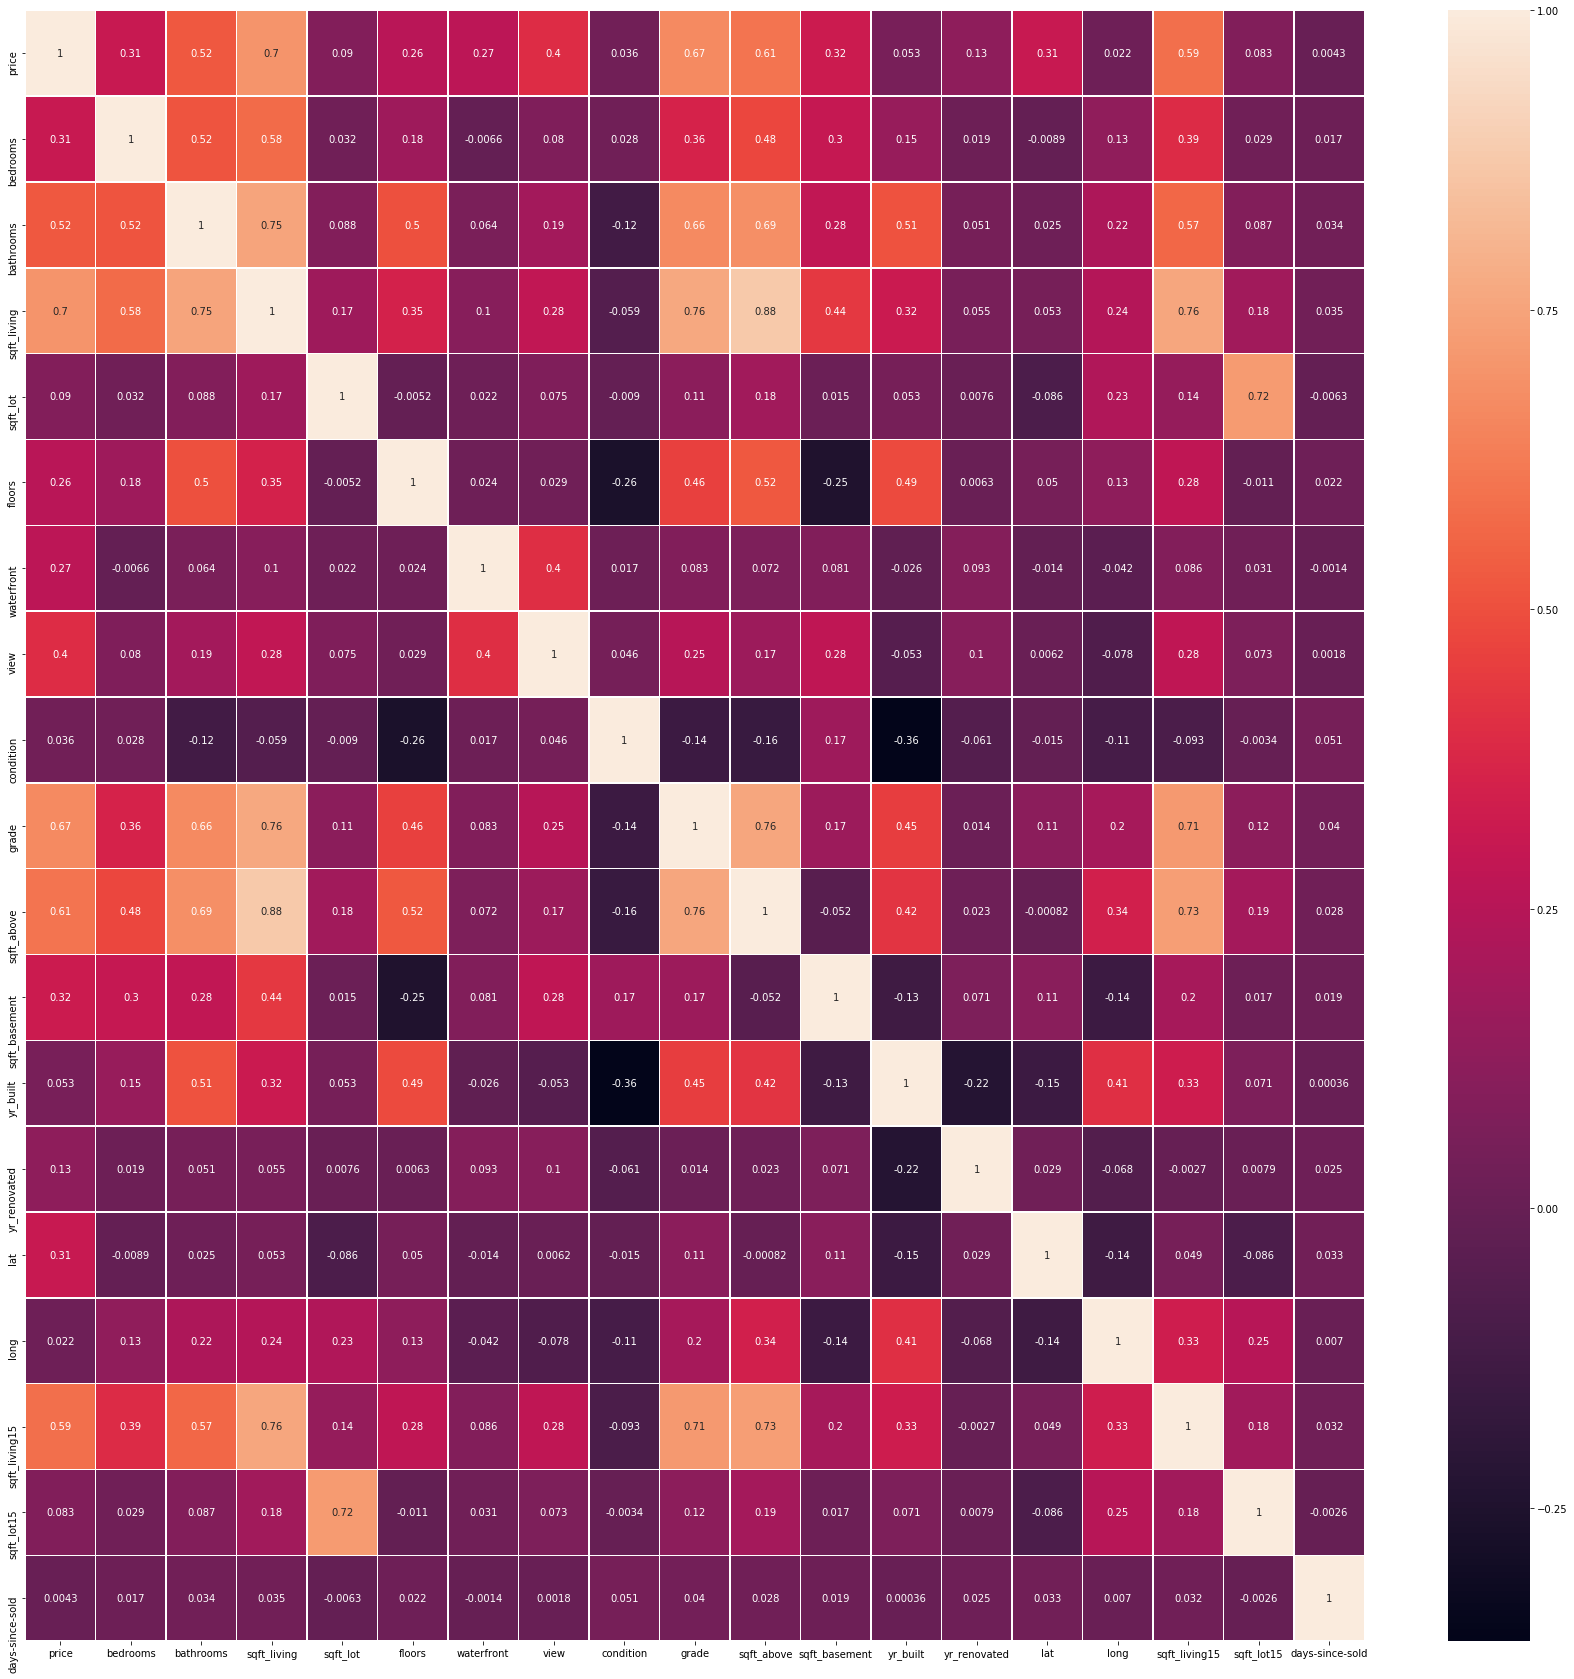

In [272]:
fig, ax = plt.subplots(figsize=(30,30))         # Sample figsize in inches
sns.heatmap(corr_data, annot=True, linewidths=.5, ax=ax)

## State your insights

#### * As per the correlation heat-map above, there are very few independent features which have co-relation of >0.8 
#### * Dependent variable "price" is having correlation with other independent features as shown in the heatmap above. 

## Build a linear regression model to predict the house prices

In [345]:
X = housing_df.drop("price", axis=1)
y = housing_df["price"]

X = X.apply(zscore)

In [346]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [349]:
m = LinearRegression()
m.fit(X_train, y_train)
y_pred = m.predict(X_test)
rmse = np.sqrt(np.mean((y_test-y_pred)**2))
print ("RMSE for Simple Linear-Regression =", rmse)

RMSE for Simple Linear-Regression = 20.581573277735654


In [350]:
m.coef_

array([-3.4861496 ,  3.19802081,  8.21103422,  0.24716666,  0.48930589,
        5.23216835,  3.6781771 ,  2.03581578, 11.03926022,  7.58884673,
        2.84040897, -7.47365894,  1.10028259,  7.80899164, -1.54080763,
        2.15041631, -0.91870533, -1.28197438])

In [351]:
m.intercept_

53.603336535121265

## Try to find out important features or create new features to improve the performance for your model.

In [352]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

In [353]:
variables= X_train.columns

#### Try Ridge to identify the feature coeffients which have less impact and fit the model  

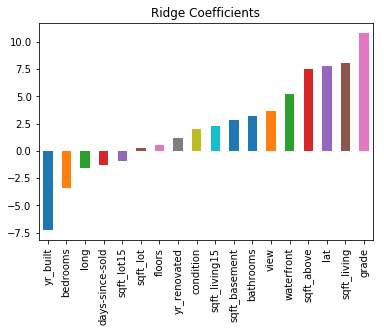

In [354]:
rd=Ridge(alpha=0.01,normalize=True)
rd.fit(X_train, y_train)
rd_pred = rd.predict(X_test)
ridge_beta=pd.Series(rd.coef_,variables).sort_values()
ridge_beta.plot(kind='bar',title='Ridge Coefficients')

In [355]:
rd_rmse = np.sqrt(np.mean((y_test-rd_pred)**2))
print ("RMSE for Ridge with Alpha 0.01 =", rd_rmse)

RMSE for Ridge with Alpha 0.01 = 20.58217352828646


#### Try Lasso to remove the feature coeffs which have less impact and fit the model  

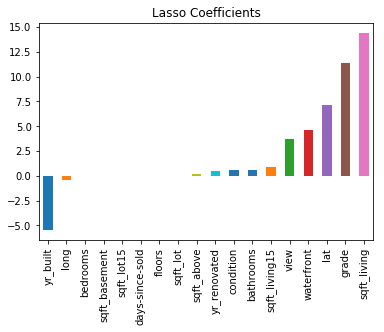

In [356]:
Ls=Lasso(alpha=0.01,normalize=True)
Ls.fit(X_train, y_train)
Ls_pred = Ls.predict(X_test)
Ls_beta=pd.Series(Ls.coef_,variables).sort_values()
Ls_beta.plot(kind='bar',title='Lasso Coefficients')

#### Important features are highlighted in the Lasso Coeff Plot, which is !=0

In [357]:
Ls_rmse = np.sqrt(np.mean((y_test- Ls_pred)**2))
print ("RMSE for Lasso with Alpha 0.01 =", Ls_rmse)

RMSE for Lasso with Alpha 0.01 = 20.95408231255058


In [358]:
coeff_used = np.sum(Ls.coef_!=0)
print ("Num of coeff_used for Lasso with Aplha 0.01:", coeff_used)

Num of coeff_used for Lasso with Aplha 0.01: 12


### Use appropriate cross validations techniques to find out the best predictor parameters and best prediction.

In [359]:
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

#### Try variuos Regression models to identify the best model and params

In [361]:
LR=LinearRegression()
knn=KNeighborsRegressor(n_neighbors=3)
bag_knn=BaggingRegressor(base_estimator=knn,n_estimators=50,random_state=seed)
bag_LR= BaggingRegressor(base_estimator=LR,n_estimators=50,random_state=seed)
boost_LR= AdaBoostRegressor(base_estimator=LR,n_estimators = 50,random_state=seed)
gboost=GradientBoostingRegressor(n_estimators=50,random_state=seed)

In [362]:
models = []
models.append(('Simple_Linear_Regression',LR))
models.append(('Bagged_LR',bag_LR))
models.append(('Boosted_LR',boost_LR))
models.append(('Simple_KNN',knn))
models.append(('GradientBoost_Reg',gboost))

In [363]:
X = housing_df.drop("price", axis=1)
Y = housing_df[["price"]]

sc=StandardScaler()
X=sc.fit_transform(X)
Y=sc.fit_transform(Y)

C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)
C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int32 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int32 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


#### Do KFold cross-val-score for R2 to identify the best model and hyper-parameters 

In [364]:
from sklearn.model_selection import KFold,cross_val_score
# evaluate each model in turn
results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=3,random_state=2)
    cv_results = cross_val_score(model, X, Y, scoring='r2', cv=kfold)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, np.mean(cv_results), np.var(cv_results))
    print(msg)

Simple_Linear_Regression: 0.691982 (0.000011)


C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\ensemble\bagging.py:397: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)
C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\ensemble\bagging.py:397: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)
C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\ensemble\bagging.py:397: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)


Bagged_LR: 0.691767 (0.000010)


C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Boosted_LR: 0.388457 (0.003353)
Simple_KNN: 0.746734 (0.000034)


C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\sthalluri\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoost_Reg: 0.835847 (0.000002)


#### Based upon the R2 result, Gradient-Boost-Regressor with R2=0.835 is the best model with n_estimator=50